<a href="https://colab.research.google.com/github/mafito90/notebooks/blob/main/DL_Tarea2b_Max_Figueroa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMOTE and ADASYN: Synthetic Oversampling Techniques for Imbalanced Data

This notebook provides a detailed explanation of **SMOTE** (Synthetic Minority Over-sampling Technique) and **ADASYN** (Adaptive Synthetic Sampling)—two powerful techniques for handling class imbalance in machine learning.

## 1. The Problem: Class Imbalance

In many real-world classification problems, we encounter **imbalanced datasets** where one class (the *minority* class) has significantly fewer samples than another (the *majority* class).

**Examples:**
- Fraud detection: 99.9% legitimate transactions, 0.1% fraud
- Medical diagnosis: rare diseases vs. healthy patients
- Spam detection: few spam emails among many legitimate ones

**Why is this a problem?**
- Standard classifiers optimize for overall accuracy, which can be achieved by predicting the majority class for everything
- The model may never learn the minority class patterns
- Metrics like accuracy become misleading (e.g., 99.9% accuracy by predicting "not fraud" always)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

### Creating an Imbalanced Dataset for Demonstration

In [17]:
# Create imbalanced dataset: 950 majority, 50 minority (95:5 ratio)
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2,
                            n_clusters_per_class=1, weights=[0.95, 0.05], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print("Training set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nMinority class: {np.sum(y_train == 1)} samples ({100*np.mean(y_train):.1f}%)")
print(f"Majority class: {np.sum(y_train == 0)} samples ({100*(1-np.mean(y_train)):.1f}%)")

Training set class distribution:
0    661
1     39
Name: count, dtype: int64

Minority class: 39 samples (5.6%)
Majority class: 661 samples (94.4%)


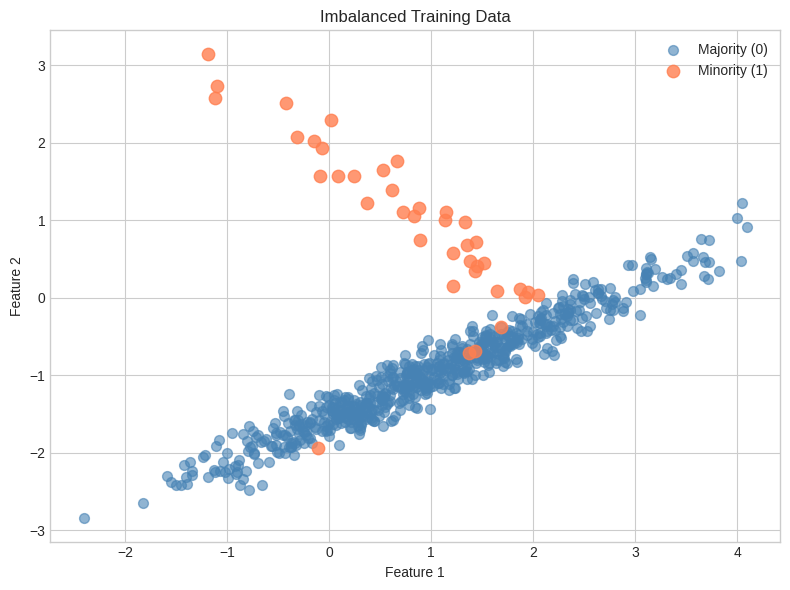

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', alpha=0.6, label='Majority (0)', s=50)
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', alpha=0.8, label='Minority (1)', s=80)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Imbalanced Training Data')
ax.legend()
plt.tight_layout()
plt.show()

---

## 2. SMOTE: Synthetic Minority Over-sampling Technique

**SMOTE** was introduced by Chawla et al. (2002) and is one of the most widely used oversampling methods.

### Key Idea
Instead of simply **duplicating** minority samples (which leads to overfitting), SMOTE creates **synthetic** samples by interpolating between existing minority instances. This expands the decision region for the minority class in a more meaningful way.

### The SMOTE Algorithm (Step by Step)

For each minority sample $x_i$:

1. **Find k nearest neighbors** of $x_i$ among other minority samples (typically k=5)

2. **Randomly select one neighbor** $x_{nn}$ from the k neighbors

3. **Create a synthetic sample** along the line segment between $x_i$ and $x_{nn}$:

   $$x_{new} = x_i + \lambda \cdot (x_{nn} - x_i)$$

   where $\lambda$ is a random number in (0, 1). This places the new point somewhere between the two original points.

4. **Repeat** until the desired minority:majority ratio is achieved

### Visual Intuition

SMOTE places new synthetic points (marked +) *between* existing minority points (*):

- **Original:** Few minority samples (*) surrounded by many majority samples (o)
- **After SMOTE:** Synthetic samples (+) fill the gaps between minority samples
- Result: A denser, more robust decision boundary for the minority class


Synthetic points (◇) fill the *space between* minority samples, creating a denser and more robust decision boundary.

### SMOTE Parameters

| Parameter | Description | Typical Value |
|-----------|-------------|---------------|
| `k_neighbors` | Number of nearest neighbors to consider | 5 |
| `sampling_strategy` | Target ratio (e.g., 'auto' for balance, or float) | 'auto' or 0.5 |
| `random_state` | Reproducibility | 42 |

### Advantages
- Reduces overfitting compared to random oversampling (no exact duplicates)
- Creates diverse synthetic samples in the feature space
- Simple and effective for many problems

### Limitations
- Treats all minority samples equally (may over-sample in already dense regions)
- Can create synthetic samples in majority-class regions (noise)
- Assumes the feature space is continuous (needs adaptation for categorical data: SMOTE-NC)

In [19]:
# Install imbalanced-learn if needed: pip install imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    !pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

In [20]:
# Apply SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE - Training set class distribution:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nTotal samples: {len(y_train_smote)} (was {len(y_train)})")

After SMOTE - Training set class distribution:
0    661
1    661
Name: count, dtype: int64

Total samples: 1322 (was 700)


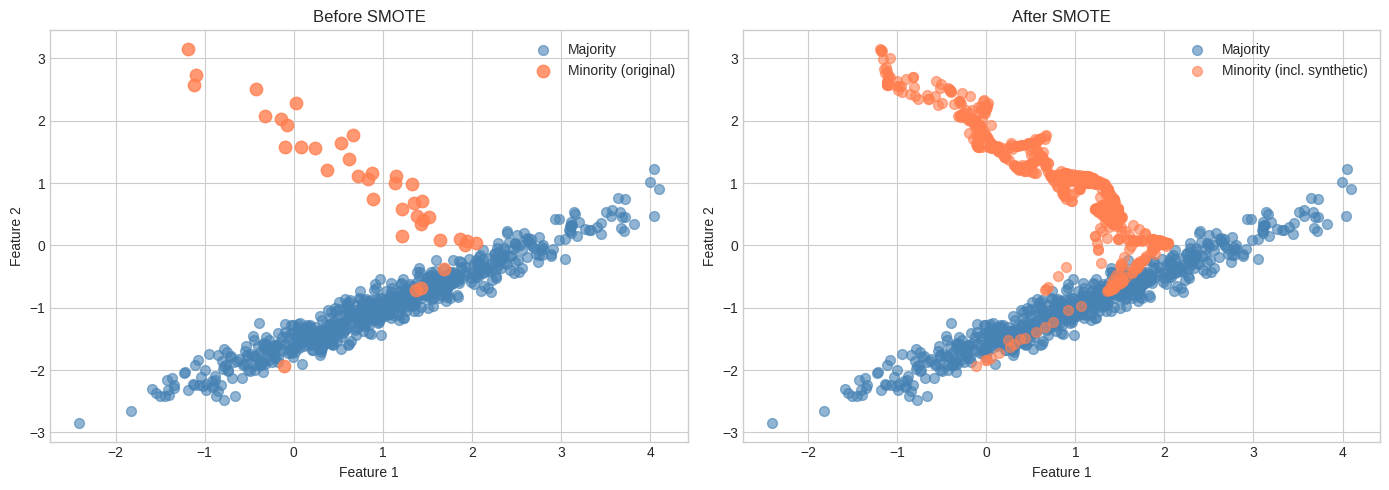

In [21]:
# Visualize SMOTE result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', alpha=0.6, label='Majority', s=50)
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', alpha=0.8, label='Minority (original)', s=80)
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()

# Identify synthetic samples (they are the "extra" minority samples)
n_original_minority = np.sum(y_train == 1)
minority_indices = np.where(y_train_smote == 1)[0]
# Original minority are first n_original in the resampled set when using fit_resample
# For visualization: show all minority (original + synthetic) in coral, majority in blue
axes[1].scatter(X_train_smote[y_train_smote==0, 0], X_train_smote[y_train_smote==0, 1], c='steelblue', alpha=0.6, label='Majority', s=50)
axes[1].scatter(X_train_smote[y_train_smote==1, 0], X_train_smote[y_train_smote==1, 1], c='coral', alpha=0.6, label='Minority (incl. synthetic)', s=50)
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 3. ADASYN: Adaptive Synthetic Sampling

**ADASYN** (He et al., 2008) is an *adaptive* extension of SMOTE. Instead of treating all minority samples equally, it focuses synthetic sample generation on **hard-to-learn** minority instances—those that are surrounded by majority samples or lie near the decision boundary.

### How ADASYN Differs from SMOTE

| Aspect | SMOTE | ADASYN |
|--------|-------|--------|
| **Strategy** | Uniform: same # of synthetics per minority sample | Adaptive: more synthetics for "difficult" samples |
| **Focus** | All minority samples equally | Borderline/hard-to-classify minority samples |
| **Weight** | No weighting | Each minority sample gets a weight ∝ local imbalance |
| **Result** | Even distribution of synthetic samples | Denser synthetic samples near decision boundary |

### The ADASYN Algorithm

1. **Compute the degree of class imbalance** and the number of synthetic samples to generate

2. **For each minority sample** $x_i$, find its k nearest neighbors and compute $r_i$ = proportion of majority samples among those neighbors (higher $r_i$ = harder to classify)

3. **Normalize** $r_i$ to get weights $\hat{r}_i$ that sum to 1

4. **For each minority sample**, generate $g_i$ synthetic samples (where $g_i$ ∝ $\hat{r}_i$)

5. **Generate each synthetic sample** using the same interpolation as SMOTE: $x_{new} = x_i + \lambda(x_{nn} - x_i)$

### When to Use ADASYN vs SMOTE

- **Use SMOTE** when minority samples are relatively well-distributed; you want a simple, uniform boost
- **Use ADASYN** when the minority class has complex structure, with some samples in "danger zones" (surrounded by majority); ADASYN will concentrate synthetic samples there

In [22]:
from imblearn.over_sampling import ADASYN

# Apply ADASYN
adasyn = ADASYN(n_neighbors=5, random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("After ADASYN - Training set class distribution:")
print(pd.Series(y_train_adasyn).value_counts().sort_index())
print(f"\nTotal samples: {len(y_train_adasyn)}")

After ADASYN - Training set class distribution:
0    661
1    659
Name: count, dtype: int64

Total samples: 1320


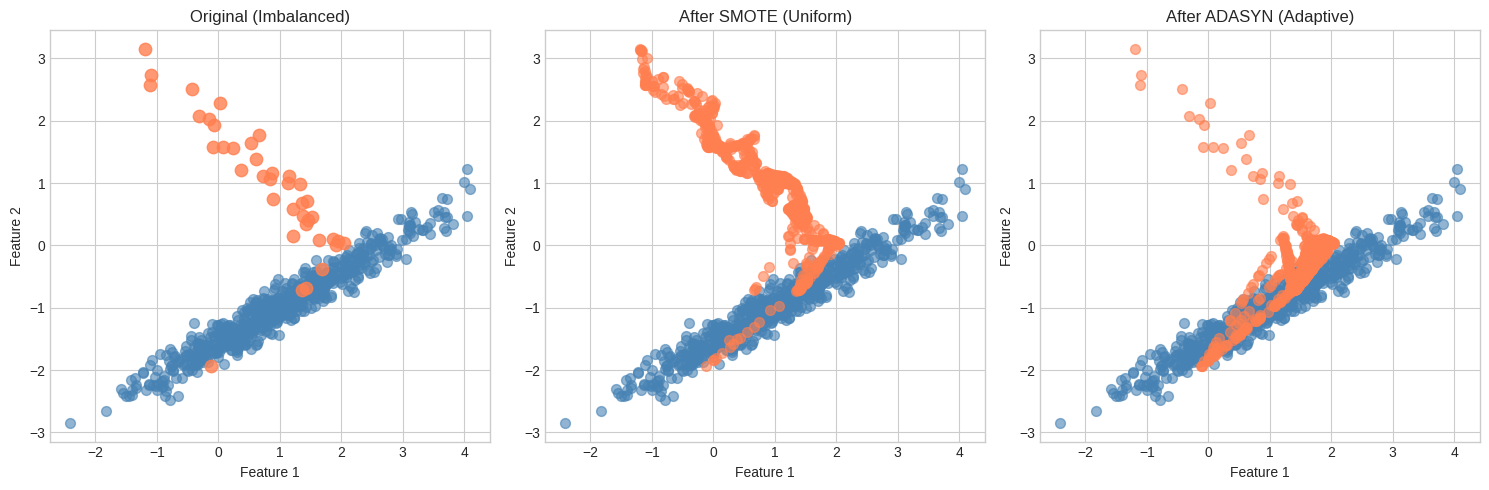

In [23]:
# Compare: Original vs SMOTE vs ADASYN
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', alpha=0.6, s=50)
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', alpha=0.8, s=80)
axes[0].set_title('Original (Imbalanced)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_train_smote[y_train_smote==0, 0], X_train_smote[y_train_smote==0, 1], c='steelblue', alpha=0.6, s=50)
axes[1].scatter(X_train_smote[y_train_smote==1, 0], X_train_smote[y_train_smote==1, 1], c='coral', alpha=0.6, s=50)
axes[1].set_title('After SMOTE (Uniform)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

axes[2].scatter(X_train_adasyn[y_train_adasyn==0, 0], X_train_adasyn[y_train_adasyn==0, 1], c='steelblue', alpha=0.6, s=50)
axes[2].scatter(X_train_adasyn[y_train_adasyn==1, 0], X_train_adasyn[y_train_adasyn==1, 1], c='coral', alpha=0.6, s=50)
axes[2].set_title('After ADASYN (Adaptive)')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

---

## 4. Practical Comparison: Model Performance

In [24]:
def train_and_evaluate(X_tr, y_tr, name):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Majority', 'Minority']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return f1_score(y_test, y_pred, pos_label=1)

f1_original = train_and_evaluate(X_train, y_train, 'Original (No Resampling)')
f1_smote = train_and_evaluate(X_train_smote, y_train_smote, 'SMOTE')
f1_adasyn = train_and_evaluate(X_train_adasyn, y_train_adasyn, 'ADASYN')


=== Original (No Resampling) ===
              precision    recall  f1-score   support

    Majority       0.97      1.00      0.99       284
    Minority       1.00      0.50      0.67        16

    accuracy                           0.97       300
   macro avg       0.99      0.75      0.83       300
weighted avg       0.97      0.97      0.97       300

Confusion Matrix:
[[284   0]
 [  8   8]]

=== SMOTE ===
              precision    recall  f1-score   support

    Majority       0.99      1.00      0.99       284
    Minority       0.92      0.75      0.83        16

    accuracy                           0.98       300
   macro avg       0.95      0.87      0.91       300
weighted avg       0.98      0.98      0.98       300

Confusion Matrix:
[[283   1]
 [  4  12]]

=== ADASYN ===
              precision    recall  f1-score   support

    Majority       0.98      0.81      0.89       284
    Minority       0.18      0.75      0.29        16

    accuracy                       

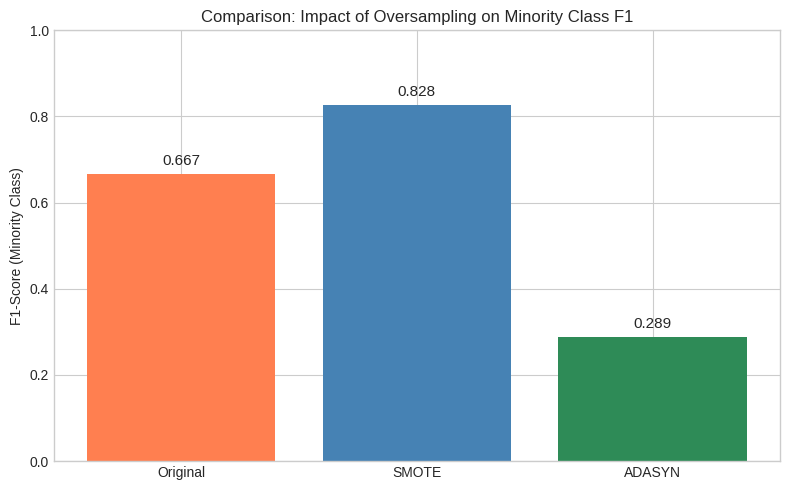

In [25]:
# F1-score comparison (minority class)
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Original', 'SMOTE', 'ADASYN']
f1_scores = [f1_original, f1_smote, f1_adasyn]
colors = ['coral', 'steelblue', 'seagreen']
bars = ax.bar(methods, f1_scores, color=colors)
ax.set_ylabel('F1-Score (Minority Class)')
ax.set_title('Comparison: Impact of Oversampling on Minority Class F1')
ax.set_ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---

## 5. Summary and Best Practices

### Key Takeaways

1. **SMOTE** creates synthetic minority samples via linear interpolation between neighbors. It is uniform and simple.

2. **ADASYN** adapts by generating more synthetic samples for minority instances that are harder to classify (near the boundary).

3. **Always apply resampling only to the training set**, never to the test set, to avoid data leakage.

4. **Use pipelines** (e.g., `imblearn.pipeline.Pipeline`) so that resampling happens within cross-validation folds correctly.

In [26]:
# Example: Using a pipeline (recommended for proper CV)
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline([
    ('smote', SMOTE(k_neighbors=5, random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)
print("Pipeline (SMOTE + LogisticRegression) - Classification Report:")
print(classification_report(y_test, y_pred_pipe, target_names=['Majority', 'Minority']))

Pipeline (SMOTE + LogisticRegression) - Classification Report:
              precision    recall  f1-score   support

    Majority       0.99      1.00      0.99       284
    Minority       0.92      0.75      0.83        16

    accuracy                           0.98       300
   macro avg       0.95      0.87      0.91       300
weighted avg       0.98      0.98      0.98       300



In [27]:
!pip install nbconvert

In [28]:
import os

# Get the current notebook name. In Colab, this is often the file you opened.
# If you saved your notebook, its name will appear in the Colab tab.
# For example, if your notebook is named 'SMOTE_ADASYN_Example.ipynb', use that.

# Alternatively, you can use a placeholder and manually input your notebook's name.
notebook_name = "/content/drive/MyDrive/Colab Notebooks/SMOTE_and_ADASYN_Explained.ipynb" # Replace with your actual notebook name

# If you are unsure of the notebook's exact name, you can also download the .ipynb file
# and then upload it to your Colab environment or Google Drive to get its path.

# Convert the notebook to HTML
!jupyter nbconvert --to html "{notebook_name}"

[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Colab Notebooks/SMOTE_and_ADASYN_Explained.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equiv

### References

- Chawla, N. V., et al. (2002). "SMOTE: Synthetic Minority Over-sampling Technique." *Journal of Artificial Intelligence Research*, 16, 321-357.
- He, H., et al. (2008). "ADASYN: Adaptive synthetic sampling approach for imbalanced learning." *IEEE International Joint Conference on Neural Networks*.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
